# 01 - Análisis exploratorio de reservas hoteleras

## Objetivo

Conocer el dataset antes de entrenar modelos: dimensiones, variable objetivo,
duplicados, valores ausentes y algunas relaciones relevantes.

**Fuente:** `data/dataset_practica_final.csv`, proporcionado por PontIA.

## 1. Importación de librerías y lectura de datos

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

RUTA_PROYECTO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RUTA_DATASET = RUTA_PROYECTO / "data" / "dataset_practica_final.csv"

df_reservas = pd.read_csv(RUTA_DATASET)
print(f"Filas: {df_reservas.shape[0]:,}")
print(f"Columnas: {df_reservas.shape[1]}")
df_reservas.head()

Filas: 119,390
Columnas: 32


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Tipos de variables y valores ausentes

In [2]:
resumen_variables = pd.DataFrame({
    "tipo": df_reservas.dtypes.astype(str),
    "nulos": df_reservas.isna().sum(),
    "porcentaje_nulos": (df_reservas.isna().mean() * 100).round(2),
    "valores_unicos": df_reservas.nunique()
})

resumen_variables.sort_values("porcentaje_nulos", ascending=False).head(10)

,tipo,nulos,porcentaje_nulos,valores_unicos
company,float64,112593,94.31,352
agent,float64,16340,13.69,333
country,object,488,0.41,177
hotel,object,0,0.00,2
previous_cancellations,int64,0,0.00,15
reservation_status,object,0,0.00,3
total_of_special_requests,int64,0,0.00,6
required_car_parking_spaces,int64,0,0.00,5
adr,float64,0,0.00,8879
customer_type,object,0,0.00,4


`company` y `agent` concentran la mayoría de valores ausentes. No eliminaremos
filas por este motivo: los valores se imputarán más adelante dentro del
preprocesamiento.

## 3. Duplicados

In [3]:
numero_duplicados = df_reservas.duplicated().sum()
print(f"Duplicados exactos: {numero_duplicados:,}")

df_reservas = df_reservas.drop_duplicates().reset_index(drop=True)
print(f"Filas después de eliminar duplicados: {len(df_reservas):,}")

Duplicados exactos: 31,994
Filas después de eliminar duplicados: 87,396


Se eliminan copias exactamente iguales antes de dividir los datos. Sin esta
precaución, una copia podría quedar en entrenamiento y otra en prueba,
produciendo una evaluación demasiado optimista.

## 4. Distribución de la variable objetivo

No cancelada    72.51
Cancelada       27.49
Name: porcentaje, dtype: float64

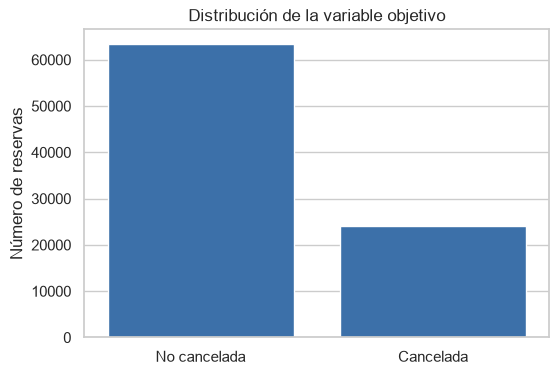

In [4]:
distribucion_objetivo = (
    df_reservas["is_canceled"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)
distribucion_objetivo.index = ["No cancelada", "Cancelada"]
display(distribucion_objetivo.round(2).rename("porcentaje"))

plt.figure(figsize=(6, 4))
sns.countplot(data=df_reservas, x="is_canceled", color="#2a6fbb")
plt.xticks([0, 1], ["No cancelada", "Cancelada"])
plt.title("Distribución de la variable objetivo")
plt.xlabel("")
plt.ylabel("Número de reservas")
plt.show()

Tras eliminar duplicados, aproximadamente el **27,5 %** de las reservas están
canceladas. Existe cierto desbalance, por lo que no utilizaremos accuracy como
única métrica.

## 5. Cancelaciones por tipo de hotel

hotel
Resort Hotel    23.48
City Hotel      30.04
Name: porcentaje_cancelacion, dtype: float64

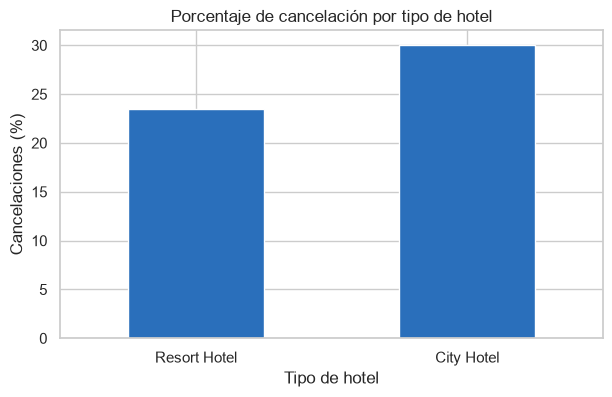

In [5]:
cancelacion_por_hotel = (
    df_reservas.groupby("hotel")["is_canceled"].mean().mul(100).sort_values()
)
display(cancelacion_por_hotel.round(2).rename("porcentaje_cancelacion"))

cancelacion_por_hotel.plot.bar(figsize=(7, 4), color="#2a6fbb")
plt.title("Porcentaje de cancelación por tipo de hotel")
plt.xlabel("Tipo de hotel")
plt.ylabel("Cancelaciones (%)")
plt.xticks(rotation=0)
plt.show()

## 6. Cancelaciones por tipo de depósito

deposit_type
Refundable    24.30
No Deposit    26.68
Non Refund    94.70
Name: porcentaje_cancelacion, dtype: float64

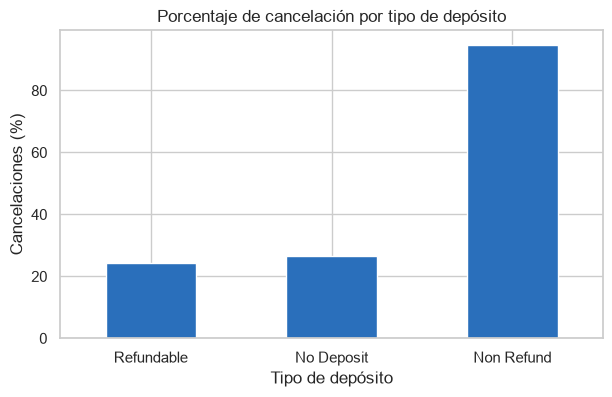

In [6]:
cancelacion_por_deposito = (
    df_reservas.groupby("deposit_type")["is_canceled"]
    .mean()
    .mul(100)
    .sort_values()
)
display(cancelacion_por_deposito.round(2).rename("porcentaje_cancelacion"))

cancelacion_por_deposito.plot.bar(figsize=(7, 4), color="#2a6fbb")
plt.title("Porcentaje de cancelación por tipo de depósito")
plt.xlabel("Tipo de depósito")
plt.ylabel("Cancelaciones (%)")
plt.xticks(rotation=0)
plt.show()

## Conclusiones del EDA

- El dataset original tiene 119.390 filas y 31.994 duplicados exactos.
- Después de eliminarlos quedan 87.396 observaciones.
- El 27,49 % corresponde a cancelaciones.
- `company` y `agent` tienen muchos valores ausentes.
- City Hotel presenta más cancelaciones que Resort Hotel.
- `deposit_type` muestra una asociación fuerte con la cancelación, aunque esta
  relación no demuestra causalidad.
- `reservation_status` y `reservation_status_date` no se utilizarán para
  entrenar porque contienen información posterior al resultado.